<a name="top" id="top"></a>

<div align="center">
    <h1>Introduction to Mathematical Programming</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/AzAINN">Azain Khalid</a>
    <br>
    <i>Department of Computer Science, Purdue University</i>
    <br>
    <i>Undergraduate Researcher</i>
    <br>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/1-MathProg.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Setup

### Google Colab
Click the badge above to open this notebook in Colab. The notebook installs or activates dependencies in the setup cells below.

### Local installation
Run the following from the repository root before opening this notebook locally:

```bash
julia --project=notebooks_jl -e 'using Pkg; Pkg.instantiate()'
```

Run the command from the repository root before opening the Julia notebook locally.

**GLPK (required for ILP sections):**
- macOS: `brew install glpk`
- Ubuntu/Debian: `sudo apt-get install glpk-utils`
- Windows: download from http://winglpk.sourceforge.net/


## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_.
2. Execute the following cell to install Julia, IJulia, the shared notebook project, and the precompiled QUBONotebooks sysimage. This can take a couple of minutes.
3. Reload this page after the installation finishes, then continue with **Activate Environment**.


In [ ]:
%%shell

bash <(curl -s "https://raw.githubusercontent.com/JuliaQUBO/QUBONotebooks/main/scripts/install-colab-julia.sh")

### Activate Environment

In [1]:
import Pkg
Pkg.activate(@__DIR__)
python_warning_filter = "ignore:invalid escape sequence:SyntaxWarning"
python_warning_filters = String.(filter(!isempty, split(get(ENV, "PYTHONWARNINGS", ""), ",")))
if python_warning_filter ∉ python_warning_filters
    push!(python_warning_filters, python_warning_filter)
    ENV["PYTHONWARNINGS"] = join(python_warning_filters, ",")
end
Pkg.instantiate(; io = devnull)


  Activating project at `./notebooks_jl`


## Learning objectives

By the end of this notebook you will be able to:

1. Formulate linear, integer, convex nonlinear, and nonconvex nonlinear programs from a word problem.
2. Implement the same optimization model family in JuMP with continuous and integer decision variables.
3. Select appropriate LP, MILP, NLP, and MINLP solvers and interpret their reported solutions.
4. Explain how integrality and nonconvexity change the difficulty and reliability of optimization workflows.


## Prerequisites

**Mathematical background:** Basic algebra, inequalities, objective functions, and familiarity with continuous and integer variables.  
**Prior notebooks:** None; this is the first Julia notebook in the sequence.  
**Accounts required:** None for the core examples; commercial solver sections require separate solver licenses.  
**Julia version:** Julia 1.10+ with the JuMP project environment used by this repository.


## Introduction to Mathematical Programming

### Modeling
The solution to optimization problems requires the development of a mathematical model. Here we will model an example given in the lecture and see how an integer program can be solved practically.
This example will use as modeling language **[JuMP](http://jump.dev/)**.
This open-source Julia package provides flexible access to different solvers and a general modeling framework for linear and nonlinear integer programs.
The examples solved here will make use of open-source solvers **[GLPK](https://www.gnu.org/software/glpk/)** and **[CLP/CBC](https://projects.coin-or.org/Cbc)** for linear and mixed-integer linear programming, **[IPOPT](https://coin-or.github.io/Ipopt/)** for interior point (non)linear programming, **[BONMIN](https://www.coin-or.org/Bonmin/)** for convex integer nonlinear programming, and **[COUENNE](https://projects.coin-or.org/Couenne)** for nonconvex (global) integer nonlinear programming.

#### Problem statement

Suppose there is a company that produces two different products, A and B, which can be sold at different values, $\$5.5$ and $\$2.1$ per unit, respectively.
The company only counts with a single machine with electricity usage of at most 17kW/day. Producing each A and B consumes $8\text{kW}/\text{day}$ and $2\text{kW}/\text{day}$, respectively.
Besides, the company can only produce at most $2$ more units of B than A per day.

### Linear Programming
This is a valid model, but it would be easier to solve if we had a mathematical representation.
Assuming the units produced of A are $x_1$ and of B are $x_2$ we have

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \le x_1 + 2 \\
                    & 8x_1 + 2x_2 \le 17 \\
                    & x_1, x_2 \ge 0
\end{array}
$$

In [2]:
# Loading in the Plots Package
using Plots

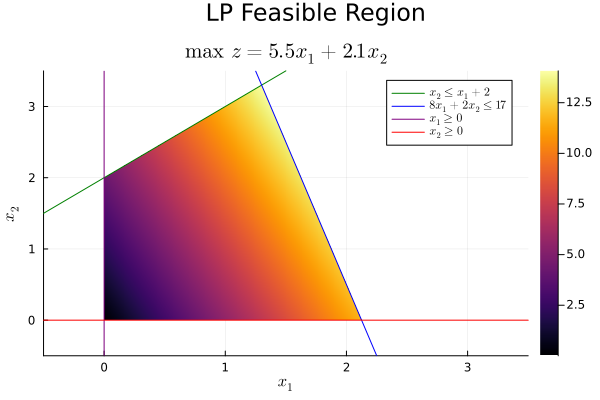

In [3]:
function plot_lp(;ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="LP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: min 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)      && # Bound: x1 ≥ 0
                         (x2 >= 0)      && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2) && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17) # Constraint 2: 8 x₁ + 2 x₂ ≤ 17

    # Heatmap function
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)

    # Plot feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ \max ~ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_lp()

In [4]:
# Loading in the modeling framework JuMP
using JuMP

In [5]:
# Define empty model
lp_model = Model()

# Define the variables
@variable(lp_model, x[1:2] >= 0)

# Define the objective function
@objective(lp_model, Max, 5.5x[1] + 2.1x[2])

# Define the constraints
@constraint(lp_model, c1, x[2] <= x[1] + 2)

@constraint(lp_model, c2, 8x[1] + 2x[2] <= 17)

# Print the model
print(lp_model)

In [6]:
# Loading in the GLPK solver
using GLPK

In [7]:
# Here we solve the optimization problem with GLPK
set_optimizer(lp_model, GLPK.Optimizer)

set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ 

objective_bound    : Inf
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 1.40800e+01
│ └ dual_objective_value : 1.40800e+01
└ Work counters
  └ solve_time (sec)   : 1.73903e-03
* x = [1.3, 3.3]


We observe that the optimal solution of this problem is $x_1 = 1.3$, $x_2 = 3.3$, leading to a profit of $14.08$.

In [8]:
# Loading in the CBC solver
using Cbc

In [9]:
# With Cbc instead:
set_optimizer(lp_model, Cbc.Optimizer)

set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : COIN Branch-and-Cut (Cbc)
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Cbc_status          = finished - check isProvenOptimal or isProvenInfeasible to see if solution found (or check value of best solution)
Cbc_secondaryStatus = unset (status_ will also be -1)

│ └ objective_bound    : 1.40800e+01
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 1.40800e+01
│ └ relative_gap         : 0.00000e+00
└ Work counters
  ├ solve_time (sec)   : 1.40595e-03
  └ node_count         : 0
* x = [1.3, 3.3]
Presolve 0 (-2) rows, 0 (-2) columns and 0 (-4) elements
Optimal - objective value 14.08
After Postsolve, objective 14.08, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 14.08 - 0 iterations time 0.002, Presolve 0.00


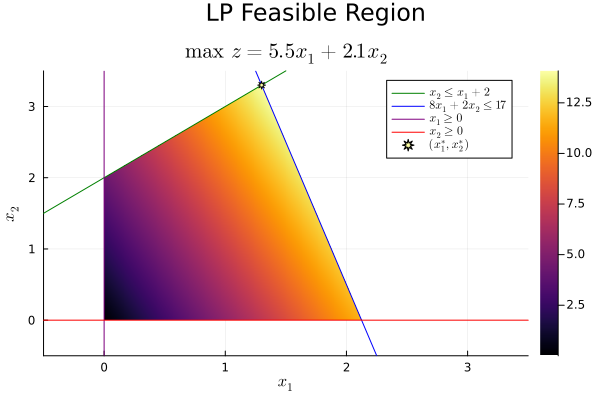

In [10]:
plot_lp(;sol = lp_x)

The solvers GLPK and CLP implement the simplex method (with many improvements) by default, but we can also use an interior point method through the solver IPOPT (interior point optimizer). IPOPT is able to solve not only linear but also nonlinear problems.

In [11]:
# Loading in the Ipopt solver
using Ipopt

In [12]:
# Using Ipopt for an interior point method
set_optimizer(lp_model, Ipopt.Optimizer)
set_silent(lp_model)

optimize!(lp_model)

# Retrieve solution value for "x"
lp_x = value.(x)

# Display solution of the problem
println(solution_summary(lp_model))
println("* x = $lp_x")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

solution_summary(; result = 1, verbose = false)
├ solver_name          : Ipopt
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 1
│ └ raw_status         : Solve_Succeeded
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 1.40800e+01
│ └ dual_objective_value : 1.40800e+01
└ Work counters
  ├ solve_time (sec)   : 1.13648e-01
  └ barrier_iterations : 8
* x = [1.3000000135344931, 3.300000029213091]


We obtain the same result as previously, but notice that the interior point method reports a solution subject to a certain tolerance, given by its convergence properties when it can get infinitesimally close (but not directly at) the boundary of the feasible region.

## From Linear Programming to Integer Programming

The LP above allows fractional decisions, which is useful for production rates but not for yes/no or count decisions. When the variables must be integers, the feasible region becomes a set of discrete points rather than a filled polygon. Solvers such as GLPK and CBC handle this by solving LP relaxations inside a branch-and-bound search. This usually makes the model harder, but it also lets the formulation represent decisions such as building 0, 1, or 2 units.


### Integer Programming

Now let's consider that only integer units of each product can be produced, namely

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \leq x_1 + 2 \\
                    & 8x_1 + 2x_2 \leq 17 \\
                    & x_1, x_2 \geq 0 \\
                    & x_1, x_2 \in \mathbb{Z}
\end{array}
$$

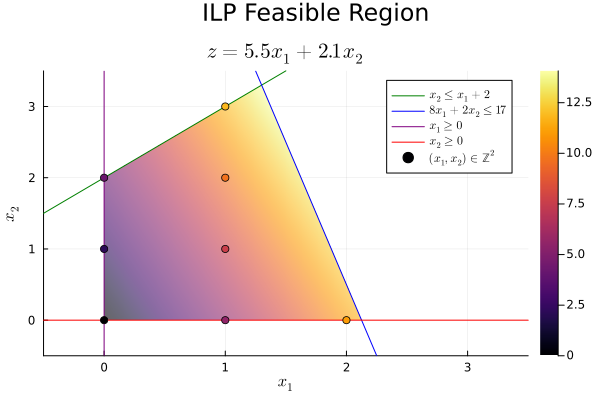

In [13]:
function plot_ilp(;ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="ILP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: min 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)      && # Bound: x1 ≥ 0
                         (x2 >= 0)      && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2) && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17) # Constraint 2: 8 x₁ + 2 x₂ ≤ 17

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2]) 

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_ilp()

In [14]:
# Copy model
ilp_model = copy(lp_model)

# Retrieve variable reference
x = ilp_model[:x]

# Add integrality contraint: x₁, x₂ ∈ ℤ
set_integer.(x)

# Print the model
print(ilp_model)

In [15]:
set_optimizer(ilp_model, Cbc.Optimizer)
set_silent(ilp_model)

optimize!(ilp_model)

print(solution_summary(ilp_model))

# Retrieve 
ilp_x = value.(x)

# Display solution of the problem
println(solution_summary(ilp_model))
println("* x = $ilp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : COIN Branch-and-Cut (Cbc)
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Cbc_status          = finished - check isProvenOptimal or isProvenInfeasible to see if solution found (or check value of best solution)
Cbc_secondaryStatus = search completed with solution

│ └ objective_bound    : 1.18000e+01
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 1.18000e+01
│ └ relative_gap         : 0.00000e+00
└ Work counters
  ├ solve_time (sec)   : 6.72698e-03
  └ node_count         : 0solution_summary(; result = 1, verbose = false)
├ solver_name          : COIN Branch-and-Cut (Cbc)
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Cbc_status          = finished - check isProvenOptimal or isProvenInfeasible to see if solution found (or check val

Here the solution becomes $x_1 = 1, x_2 = 3$ with an objective of $11.8$.

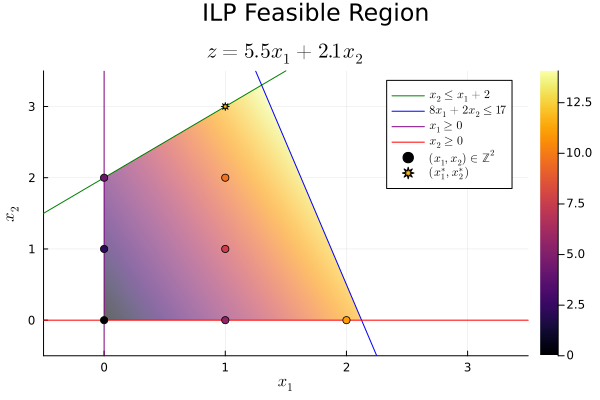

In [16]:
plot_ilp(; sol = ilp_x)

## Why enumeration stops scaling

The previous ILP is small enough that listing feasible integer points is informative. Enumeration is useful here because it exposes the shape of the discrete feasible set and checks the solver result by hand. It stops being practical quickly: adding variables or increasing bounds multiplies the number of candidates before the solver even evaluates the objective.


#### Enumeration
Enumerating all the possible solutions in this problem might be very efficient (there are only 8 feasible solutions), this we only know from the plot. Assuming that we had as upper bounds for the variables 4, the possible solutions would be 16. With a larger number of variables, the enumeration turns to be impractical. For $n$ binary variables (we can always "binarize" the integer variables), the number of possible solutions is $2^n$.

In many other applications, the possible solutions come from permutations of the integer variables (e.g., assignment problems), which grow as $n!$ with the size of the input.

This growth makes the problem grow out of control relatively quickly.

In [17]:
# Loading in SpecialFunctions package that provides a range of mathematical functions
using SpecialFunctions

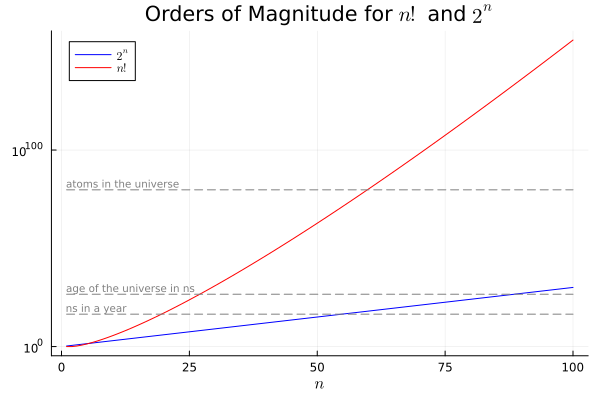

In [18]:
function plot_growth(n::Integer = 100)
    i = 1:n

    plt = plot(;
        title=raw"Orders of Magnitude for $ n! $ and $ 2^n $",
        xlabel=raw"$ n $",
        legend=:topleft,
        yscale=:log10,
    )

    plot!(plt, i, (i) -> 2.0^i; label=raw"$ 2^n $", color=:blue)
    plot!(plt, i, SpecialFunctions.gamma; label=raw"$ n! $", color=:red)

    plot!(plt, i, (i) -> 3.154E16; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 3.154E16, text("ns in a year", :gray, :left, :bottom, 7))

    plot!(plt, i, (i) -> 4.3E26; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 4.3E26, text("age of the universe in ns", :gray, :left, :bottom, 7))

    plot!(plt, i, (i) -> 6E79; color=:gray, label = nothing, linestyle = :dash)
    annotate!(plt, first(i), 6E79, text("atoms in the universe", :gray, :left, :bottom, 7))

    return plt
end

plot_growth()

## From Integer Linear Programming to Integer Nonlinear Programming

### Integer convex nonlinear programming

The following constraint: "the production of B minus 1, squared, can only be smaller than 2 minus the production of A" can be incorporated  in the following convex integer nonlinear program, 

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2        \\
    \textrm{s.t.}   & x_2 \leq x_1 + 2       \\
                    & 8x_1 + 2x_2 \leq 17    \\
                    & (x_2-1)^2 \leq 2 - x_1 \\
                    & x_1, x_2 \geq 0        \\
                    & x_1, x_2 \in \mathbb{Z}
\end{array}
$$

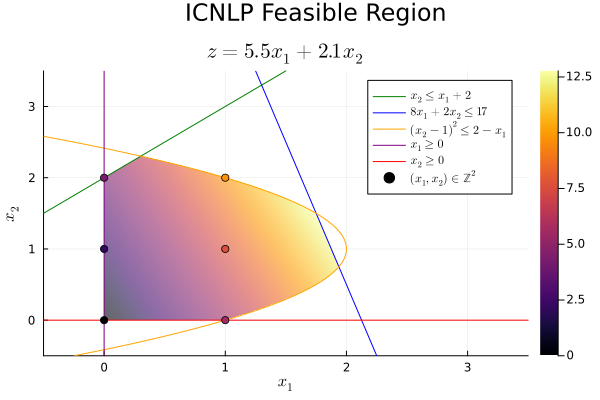

In [19]:
function plot_icnlp(; ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="ICNLP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: min 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)           && # Bound: x1 ≥ 0
                         (x2 >= 0)           && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2)      && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17)   && # Constraint 2: 8 x₁ + 2 x₂ ≤ 17
                         ((x2 - 1)^2 <= 2 - x1) # Constraint 3: (x₂ - 1)² ≤ 2 - x₁

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2]) 

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )
    plot!(plt, 2 .- (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \leq 2 - x_1 $",
        color=:orange,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [sol[1]], [sol[2]];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_icnlp()

In [20]:
# Define the model
icnlp_model = copy(ilp_model)

# Retrieve variable reference
x = icnlp_model[:x]

# (x₂ - 1)² ≤ 2 - x₁
@constraint(icnlp_model, c3, (x[2] - 1)^2 <= 2 - x[1])

# Print the model
print(icnlp_model)

In [21]:
# BONMIN Solver
using AmplNLWriter
using Bonmin_jll

Bonmin_Optimizer() = AmplNLWriter.Optimizer(Bonmin_jll.amplexe);

In [22]:
set_optimizer(icnlp_model, Bonmin_Optimizer)

optimize!(icnlp_model)

icnlp_x = value.(x)

println(solution_summary(icnlp_model))
println("* x = $icnlp_x")

Bonmin 1.8.9 using Cbc 2.10.12 and Ipopt 3.14.19
bonmin: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

NLP0012I 
              Num      Status      Obj             It       time                 Location
NLP0014I             1         OPT -12.775        9 0.001859
NLP0012I 
              Num      Status      Obj             It       time                 Location
NLP0014I             1      INFEAS 0.24999981       16 0.003011
NLP0014I             2         OPT -12.4125        5 0.000759
NLP0014I             3         OPT -9.7000002        6 0.000771
NLP0014I             4         OPT -9.7000001        6 0.000733
NLP0014I             5      INFEAS 0.249

solution_summary(; result = 1, verbose = false)
├ solver_name          : AmplNLWriter
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 1
│ └ raw_status         : bonmin: Optimal
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ └ objective_value      : 9.70000e+00
└ Work counters
  └ solve_time (sec)   : 1.77548e-01
* x = [1.0, 2.0]


In this case the optimal solution becomes $x_1 = 1, x_2 = 2$ with an objective of $9.7$.

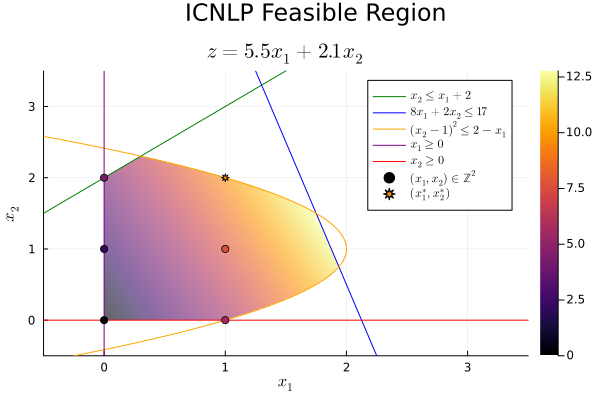

In [23]:
plot_icnlp(; sol = icnlp_x)

### Integer non-convex programming

The last constraint "the production of B minus 1 squared can only be greater than the production of A plus one half" can be incorporated in the following non-convex integer nonlinear program.

To see why, define $g(x_1, x_2) = (x_2 - 1)^2 - x_1 - \frac{1}{2}$. This is a convex function, but the constraint $g(x_1, x_2) \geq 0$ is a superlevel-set constraint. Equivalently, it removes the convex sublevel set $g(x_1, x_2) < 0$, leaving a feasible region that is generally non-convex.

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \leq x_1 + 2 \\
                    & 8x_1 + 2x_2 \leq 17 \\
                    & (x_2-1)^2 \leq 2-x_1\\
                    & (x_2-1)^2 \geq \frac{1}{2} +x_1\\
                    & x_1, x_2 \geq 0 \\
                    & x_1, x_2 \in \mathbb{Z}
\end{array}
$$

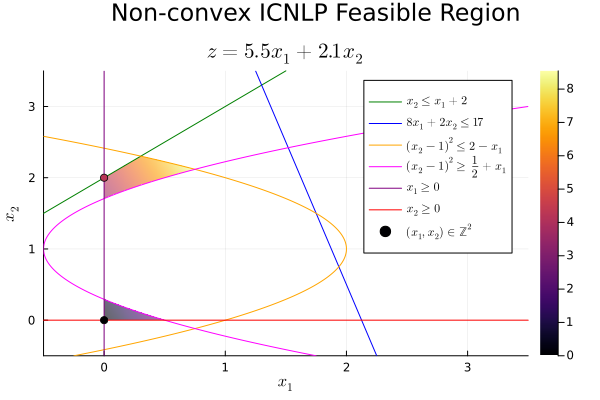

In [24]:
function plot_incnlp(; ns::Integer = 1_000, sol = nothing)
    # Create empty plot
    plt = plot(;
        plot_title="Non-convex ICNLP Feasible Region",
        plot_titlevspan=0.1,
    )

    # Generate the feasible region plot of this problem
    x1 = x2 = range(-0.5, 3.5; length = ns)

    # Objective: min 5.5x₁ + 2.1x₂
    z(x1, x2) = 5.5x1 + 2.1x2

    # Constraints
    isfeasible(x1, x2) = (x1 >= 0)              && # Bound: x1 ≥ 0
                         (x2 >= 0)              && # Bound: x2 ≥ 0
                         (x2 <= x1 + 2)         && # Constraint 1: x₂ ≤ x₁ + 2
                         (8x1 + 2x2 <= 17)      && # Constraint 2: 8 x₁ + 2 x₂ ≤ 17
                         ((x2 - 1)^2 <= 2 - x1) && # Constraint 3: (x₂ - 1)² ≤ 2 - x₁
                         ((x2 - 1)^2 >= 1/2 + x1)  # Constraint 4: (x₂ - 1)² ≥ 1/2 + x₁

    # Optimal Solution
    isoptimal(x1, x2) = (sol !== nothing) && (x1 ≈ sol[1] && x2 ≈ sol[2])

    # Heatmap functions
    f(x1, x2) = ifelse(isfeasible(x1, x2), z(x1, x2), NaN)
    g(x1, x2) = ifelse(isfeasible(x1, x2), 1.0, NaN)

    # Plot relaxed feasible region
    heatmap!(
        plt, x1, x2, f;
        legend=:topright,
        title=raw"$ z = 5.5 x_1 + 2.1 x_2 $",
        colorbar_label=raw"$ z $",
        xlims=extrema(x1),
        ylims=extrema(x2),
        xlabel=raw"$ x_1 $",
        ylabel=raw"$ x_2 $",
    )

    # Dim relaxed feasible region
    heatmap!(
        plt, x1, x2, g;
        alpha=0.4,
        color=:white,
        colorbar_entry=false,
        xlims=extrema(x1),
        ylims=extrema(x2),
    )

    # Make plots of constraints
    plot!(plt, x1, (x1) -> x1 + 2;
        label=raw"$ x_2 \leq x_1 + 2 $",
        color=:green,
    )
    plot!(plt, x1, (x1) -> (17 - 8x1) / 2;
        label=raw"$ 8 x_1 + 2 x_2 \leq 17 $",
        color=:blue,
    )
    plot!(plt, 2 .- (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \leq 2 - x_1 $",
        color=:orange,
    )
    plot!(plt, -1/2 .+ (x1 .- 1) .^ 2, x1,;
        label=raw"$ (x_2 - 1)^2 \geq \frac{1}{2} + x_1 $",
        color=:magenta,
    )

    # Nonnegativitivy constraints
    plot!(plt, zeros(ns), x2;
        label=raw"$ x_1 \geq 0 $",
        color=:purple,
    )
    plot!(plt, x1, zeros(ns);
        label=raw"$ x_2 \geq 0 $",
        color=:red,
    )

    # Feasible solutions
    xi = []
    xj = []

    for i = 0:4, j = 0:4
        if isfeasible(i, j) && !isoptimal(i, j)
            push!(xi, i)
            push!(xj, j)
        end
    end

    scatter!(plt, xi, xj;
        label=raw"$ (x_1, x_2) \in \mathbb{Z}^2 $",
        marker_z=z,
    )

    if sol !== nothing
        # Optimal solution
        scatter!(plt, [round(sol[1])], [round(sol[2])];
            label=raw"$ (x_1^\ast, x_2^\ast) $",
            marker_z=z,
            markershape=:star8,
        )
    end

    return plt
end

plot_incnlp()

In [25]:
# Define the model
incnlp_model = copy(icnlp_model)

# Retrieve variable reference
x = incnlp_model[:x]

# (x₂ - 1)² ≥ 1/2 + x₁
@constraint(incnlp_model, c4, (x[2] - 1)^2 >= 1/2 + x[1])

# Print the model
print(incnlp_model)

In [26]:
# Trying to solve the problem with BONMIN we might obtain the optimal solution,
# but we have no guarantees
set_optimizer(incnlp_model, Bonmin_Optimizer)

optimize!(incnlp_model)

# println(solution_summary(incnlp_model)) # Uncomment to print out the solution summary

if result_count(incnlp_model) > 0
    incnlp_x = value.(x)

    println("* x = $incnlp_x")
end

Bonmin 1.8.9 using Cbc 2.10.12 and Ipopt 3.14.19
bonmin: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



bonmin: BonHeuristicDiveMIP.cpp:133: virtual int Bonmin::HeuristicDiveMIP::solution(double&, double*): Assertion `isNlpFeasible(minlp, primalTolerance)' failed.


In [27]:
# COUENNE Solver
using Couenne_jll

Couenne_Optimizer() = AmplNLWriter.Optimizer(Couenne_jll.amplexe);

In [28]:
# Trying to solve the problem with global MINLP solver COUENNE
set_optimizer(incnlp_model, Couenne_Optimizer)

optimize!(incnlp_model)

println(solution_summary(incnlp_model))

if result_count(incnlp_model) > 0
    incnlp_x = value.(x)

    println("* x = $incnlp_x")
end

Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions: http://www.coin-or.org/Couenne
couenne: 
ANALYSIS TEST: NLP0012I 
              Num      Status      Obj             It       time                 Location
NLP0014I             1         OPT -2.7500001        8 1e-06
Couenne: new cutoff value 0.0000000000e+00 (0.019011 seconds)
NLP0014I             2         OPT -0        0 0
Loaded instance "<TEMPORARY_PATH>"
Constraints:            4
Variables:              2 (2 integer)
Auxiliaries:            5 (4 integer)

Coin0506I Presolve 6 (-2) rows, 3 (-4) columns and 14 (-8) elements
Clp0006I 0  Obj 0 Dual inf 7.599998 (2)
Clp0006I 4  Obj -6.95
Clp0000I Optimal - objective value -6.95
Clp0032I Optimal objective -6.95 - 4 iterations time 0.002, Presolve 0.00
Clp0000I Optimal - objective value -6.95
NLP Heuristic: Couenne: new cutoff value -4.2000000000e+00 (0.019011 seconds)
NLP0014I             3         OPT -4

In this case the optimal solution becomes $x_1 = 0, x_2 = 2$ with an objective of $4.2$.

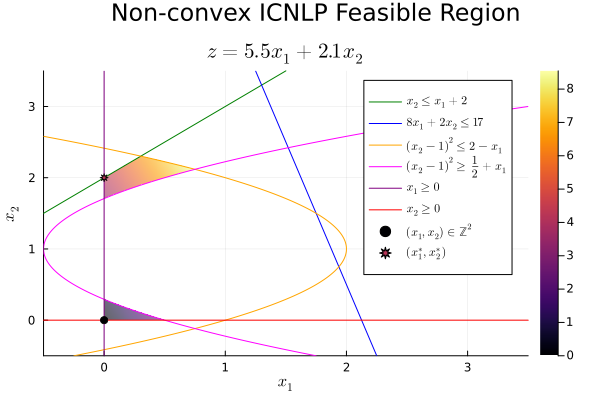

In [29]:
plot_incnlp(; sol = incnlp_x)

We are able to solve non-convex MINLP problems. However, the complexity of these problems leads to significant computational challenges that need to be tackled.

## Practice checkpoints

Use these checkpoints during the workshop to test the main ideas before moving on.

In [30]:
# =============================================================================
# EXERCISE 1: Change the objective sense
# =============================================================================
# Create a scratch version of the linear model that minimizes the same linear expression instead of maximizing it. Compare the new solution with the original optimum and identify which active constraints changed.
#
# Hint: Keep the feasible region unchanged so only the objective direction changes.
#
# Your code here:
# =============================================================================

In [31]:
# SOLUTION (hidden in workshop version):
# Scratch objective-sense check on representative feasible corner points.
candidate_points = [(0.0, 0.0), (4.0, 0.0), (0.0, 6.0), (2.0, 3.0)]
objective(point) = 5.5 * point[1] + 2.1 * point[2]
objective_pairs = sort([(point, objective(point)) for point in candidate_points]; by = item -> item[2])
minimizer = objective_pairs[1][1]
maximizer = objective_pairs[end][1]
println("minimizer = $(minimizer); maximizer = $(maximizer)")


minimizer = (0.0, 0.0); maximizer = (4.0, 0.0)


In [32]:
# =============================================================================
# EXERCISE 2: Add an integrality constraint
# =============================================================================
# Choose one continuous decision variable and restrict it to integer values. Re-solve the model and describe whether the objective value changes because the feasible set became smaller.
#
# Hint: Use a copied model or a fresh variable declaration so the original demonstration remains reproducible.
#
# Your code here:
# =============================================================================

In [33]:
# SOLUTION (hidden in workshop version):
# Compare a continuous incumbent with nearby integer candidates.
continuous_solution = (2.4, 1.6)
integer_candidates = [(2, 1), (2, 2), (3, 1), (3, 2)]
objective(point) = 5.5 * point[1] + 2.1 * point[2]
best_integer = sort(integer_candidates; by = objective, rev = true)[1]
println("continuous = $(continuous_solution); best_integer = $(best_integer)")


continuous = (2.4, 1.6); best_integer = (3, 2)


In [34]:
# =============================================================================
# EXERCISE 3: Explain a new constraint geometrically
# =============================================================================
# Add one additional linear constraint that cuts off part of the original feasible region. Sketch or describe which side of the line remains feasible and predict the effect before solving.
#
# Hint: Pick a simple bound such as a weighted sum of the two plotted variables.
#
# Your code here:
# =============================================================================

In [35]:
# SOLUTION (hidden in workshop version):
# Check which candidate points survive a new linear constraint.
candidate_points = [(0, 0), (4, 0), (0, 6), (2, 3), (3, 2)]
satisfies_new_constraint(point) = point[1] + point[2] <= 4
remaining_points = filter(satisfies_new_constraint, candidate_points)
println("remaining_feasible_points = $(remaining_points)")


remaining_feasible_points = [(0, 0), (4, 0)]


## Summary

In this notebook we:

- Built optimization models for a production-planning example across LP, ILP, convex INLP, and nonconvex INLP forms.
- Used JuMP to declare variables, objectives, and constraints, then called solvers suited to each model class.
- Compared how relaxations, integer restrictions, nonlinear constraints, and nonconvexity affect solution quality and solver behavior.

**Learning objectives met:** You practiced formulating optimization models, implementing them in JuMP, choosing solver classes, and interpreting solver output across increasingly difficult model families.

**Next steps:** Proceed to [Notebook 2: QUBO and Ising Models](2-QUBO.ipynb) to learn how constrained binary models can be rewritten as unconstrained quadratic objectives.

**Further reading:**
- [JuMP documentation](https://jump.dev/JuMP.jl/stable/)
- [Ipopt.jl documentation](https://jump.dev/JuMP.jl/stable/packages/Ipopt/)
- [GLPK.jl documentation](https://jump.dev/JuMP.jl/stable/packages/GLPK/)


# References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

## Local Installation Instructions

If you don't have a Julia installation yet, consider using [juliaup](https://github.com/JuliaLang/juliaup).
Otherwise, run the next cell to install the necessary packages.

### Validate Julia Installation

In [36]:
versioninfo()

Julia Version 1.10.11
Commit a2b11907d7b (2026-03-09 14:59 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 36 × Intel(R) Xeon(R) w5-2565X
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, sapphirerapids)
Threads: 1 default, 0 interactive, 1 GC (on 36 virtual cores)
Environment:
  JULIA_DEPOT_PATH = <LOCAL_JULIA_DEPOT>:<JULIA_DEPOT>
  JULIA_PKG_PRECOMPILE_AUTO = 0


### Install Julia Packages

## Installing Powerful commercial solvers

### Gurobi

Gurobi is one of the most powerful LP and MIP solvers available today.
They provide free academic licenses.
In order to install the software, visit their **[Website](https://www.gurobi.com/)**, create an account (preferably with your academic email), and obtain a license.
Once you do that, you can download and use the software.

### BARON

BARON is one of the most powerful MINLP solvers available today.
Students from the University System of Georgia or CMU and UIUC affiliates are eligible for a free license. 
In order to install the software, visit their **[Website](https://www.minlp.com/home)**, create an account (with your academic email), and obtain a license.
Once you do that you can download and use the software.

<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>